<a href="https://colab.research.google.com/github/ngstephen1/Deloitte-pi-rates/blob/main/dataframe.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np

In [4]:
csvfile = pd.read_csv('/content/bank_transactions_data_2.csv')

In [5]:
print(csvfile)

     TransactionID AccountID  TransactionAmount      TransactionDate  \
0         TX000001   AC00128              14.09  2023-04-11 16:29:14   
1         TX000002   AC00455             376.24  2023-06-27 16:44:19   
2         TX000003   AC00019             126.29  2023-07-10 18:16:08   
3         TX000004   AC00070             184.50  2023-05-05 16:32:11   
4         TX000005   AC00411              13.45  2023-10-16 17:51:24   
...            ...       ...                ...                  ...   
2507      TX002508   AC00297             856.21  2023-04-26 17:09:36   
2508      TX002509   AC00322             251.54  2023-03-22 17:36:48   
2509      TX002510   AC00095              28.63  2023-08-21 17:08:50   
2510      TX002511   AC00118             185.97  2023-02-24 16:24:46   
2511      TX002512   AC00009             243.08  2023-02-14 16:21:23   

     TransactionType          Location DeviceID      IP Address MerchantID  \
0              Debit         San Diego  D000380  162.198.

In [7]:
csvfile.columns

Index(['TransactionID', 'AccountID', 'TransactionAmount', 'TransactionDate',
       'TransactionType', 'Location', 'DeviceID', 'IP Address', 'MerchantID',
       'Channel', 'CustomerAge', 'CustomerOccupation', 'TransactionDuration',
       'LoginAttempts', 'AccountBalance', 'PreviousTransactionDate'],
      dtype='object')

______________________________________________________________________________________________________________

In [8]:
df_copy = csvfile.copy()

In [43]:
df = df_copy.drop(columns = ['TransactionID', 'AccountID', 'Location','IP Address', 'MerchantID', 'DeviceID', 'TransactionDate', 'PreviousTransactionDate'] )

In [44]:
print(df)

      TransactionAmount TransactionType Channel  CustomerAge  \
0                 14.09           Debit     ATM           70   
1                376.24           Debit     ATM           68   
2                126.29           Debit  Online           19   
3                184.50           Debit  Online           26   
4                 13.45          Credit  Online           26   
...                 ...             ...     ...          ...   
2507             856.21          Credit  Branch           33   
2508             251.54           Debit  Branch           48   
2509              28.63           Debit  Branch           56   
2510             185.97           Debit  Online           23   
2511             243.08          Credit  Online           24   

     CustomerOccupation  TransactionDuration  LoginAttempts  AccountBalance  
0                Doctor                   81              1         5112.21  
1                Doctor                  141              1        13758.91

In [45]:
df['TransactionType'].unique()

array(['Debit', 'Credit'], dtype=object)

In [46]:
df['Channel'].unique()

array(['ATM', 'Online', 'Branch'], dtype=object)

In [47]:
df['CustomerOccupation'].unique()

array(['Doctor', 'Student', 'Retired', 'Engineer'], dtype=object)

In [48]:
df['TransactionType'] = df['TransactionType'].replace({
    'Debit': 0,
    'Credit': 1,
})

/tmp/ipykernel_28116/3366859864.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['TransactionType'] = df['TransactionType'].replace({


In [49]:
df['Channel'] = df['Channel'].replace({
    'ATM': 0,
    'Online': 1,
    'Branch': 2,
})

/tmp/ipykernel_28116/968876174.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Channel'] = df['Channel'].replace({


In [72]:
df['CustomerOccupation'] = df['CustomerOccupation'].replace({
    'Student': 0,
    'Doctor': 1,
    'Retired': 2,
    'Engineer':3
})

In [73]:
print(df)

      TransactionAmount  TransactionType  Channel  CustomerAge  \
0                 14.09                0        0           70   
1                376.24                0        0           68   
2                126.29                0        1           19   
3                184.50                0        1           26   
4                 13.45                1        1           26   
...                 ...              ...      ...          ...   
2507             856.21                1        2           33   
2508             251.54                0        2           48   
2509              28.63                0        2           56   
2510             185.97                0        1           23   
2511             243.08                1        1           24   

      CustomerOccupation  TransactionDuration  LoginAttempts  AccountBalance  
0                      0                   81              1         5112.21  
1                      0                  141    

In [75]:
df.describe()

,TransactionAmount,TransactionType,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance
count,2512.000000,2512.000000,2512.000000,2512.000000,2512.000000,2512.000000,2512.000000,2512.000000
mean,297.593778,0.226115,1.013933,44.673965,1.484873,119.643312,1.124602,5114.302966
std,291.946243,0.418398,0.822937,17.792198,1.118154,69.963757,0.602662,3900.942499
min,0.260000,0.000000,0.000000,18.000000,0.000000,10.000000,1.000000,101.250000
25%,81.885000,0.000000,0.000000,27.000000,0.000000,63.000000,1.000000,1504.370000
50%,211.140000,0.000000,1.000000,45.000000,1.000000,112.500000,1.000000,4735.510000
75%,414.527500,0.000000,2.000000,59.000000,2.000000,161.000000,1.000000,7678.820000
max,1919.110000,1.000000,2.000000,80.000000,3.000000,300.000000,5.000000,14977.990000


In [80]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.05, random_state=42)  # 5% anomalies expected
df['fraud_flag'] = iso.fit_predict(df)

# -1 = anomaly, 1 = normal
fraud_cases = df[df['fraud_flag'] == -1]

print(fraud_cases)

      TransactionAmount  TransactionType  Channel  CustomerAge  \
26               246.93                0        0           23   
32               396.45                0        0           49   
85              1340.19                1        1           54   
91               223.85                0        0           53   
113              213.76                1        0           78   
...                 ...              ...      ...          ...   
2371              21.23                0        0           23   
2380            1173.74                1        1           61   
2423             332.06                0        0           29   
2445             403.01                0        1           63   
2507             856.21                1        2           33   

      CustomerOccupation  TransactionDuration  LoginAttempts  AccountBalance  \
26                     1                  158              5          673.35   
32                     3                  168  

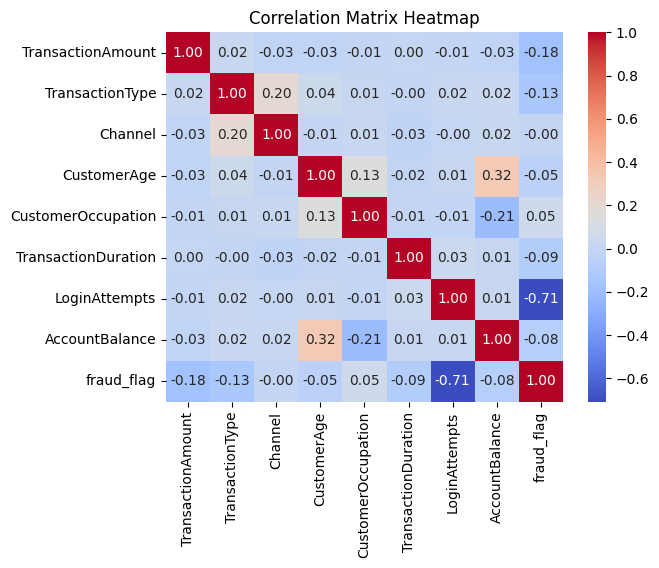

In [81]:

#correlation matrix after dropping some of the columns
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix Heatmap')
plt.show()

In [65]:
# Example for one column
Q1 = df['LoginAttempts'].quantile(0.25)
Q3 = df['LoginAttempts'].quantile(0.75)
IQR = Q3 - Q1

# Define outlier boundaries
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter outliers
outliers = df[(df['LoginAttempts'] < lower_bound) | (df['LoginAttempts'] > upper_bound)]
print(outliers)

      TransactionAmount  TransactionType  Channel  CustomerAge  \
23               345.84                0        1           22   
26               246.93                0        0           23   
32               396.45                0        0           49   
38               795.31                0        0           66   
61               263.99                0        2           79   
...                 ...              ...      ...          ...   
2423             332.06                0        0           29   
2445             403.01                0        1           63   
2455             655.81                0        0           55   
2457              79.92                0        0           44   
2492             267.48                0        0           21   

      CustomerOccupation  TransactionDuration  LoginAttempts  AccountBalance  
23                     1                  142              3         1402.50  
26                     1                  158    

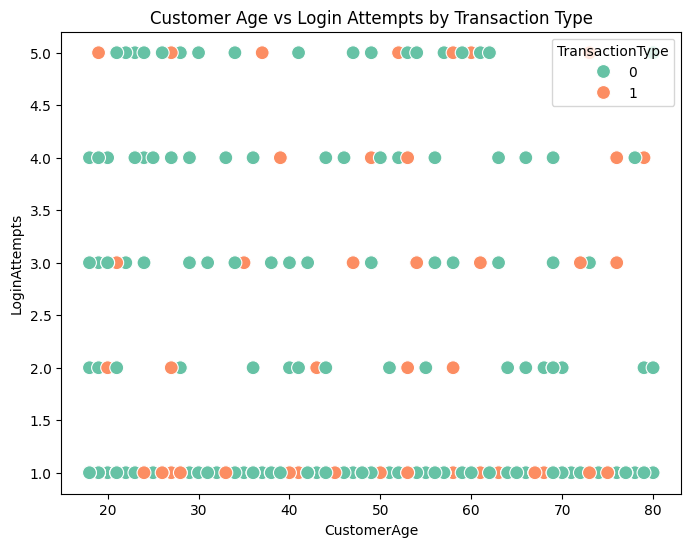